# Standardized DeepHit Baseline (Model Package Import)

## 1. Import Required Libraries

In [1]:
import importlib
import os
import subprocess
import sys

MAMBA_REQ = "mamba-ssm==2.3.1"
CAUSAL_REQ = "causal-conv1d==1.6.1"
EINOPS_REQ = "einops>=0.7"

# Keep this False for normal runs. Set True only once if your env is missing packages.
AUTO_INSTALL_MAMBA_IN_ENV = False


def _module_exists(module_name: str) -> bool:
    try:
        return importlib.util.find_spec(module_name) is not None
    except Exception:
        return False


def _safe_import_version(module_name: str) -> tuple[bool, str | None, str | None]:
    """Return (ok, version, error_message) without crashing the cell."""
    try:
        module = importlib.import_module(module_name)
        version = getattr(module, "__version__", "unknown")
        return True, str(version), None
    except Exception as exc:
        return False, None, f"{type(exc).__name__}: {exc}"


print("Python:", sys.executable)
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV", ""))

have_causal = _module_exists("causal_conv1d")
have_mamba = _module_exists("mamba_ssm")

if not (have_causal and have_mamba) and AUTO_INSTALL_MAMBA_IN_ENV:
    print("Installing mamba dependencies into active environment...")
    try:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "pip",
            "setuptools",
            "wheel",
            "ninja",
            EINOPS_REQ,
        ])
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--no-build-isolation",
            "--upgrade",
            CAUSAL_REQ,
            MAMBA_REQ,
        ])
    except subprocess.CalledProcessError as exc:
        print(f"Auto-install failed: {exc}")

causal_ok, causal_ver, causal_err = _safe_import_version("causal_conv1d")
mamba_ok, mamba_ver, mamba_err = _safe_import_version("mamba_ssm")

print("causal_conv1d:", causal_ver if causal_ok else f"broken ({causal_err})")
print("mamba_ssm:", mamba_ver if mamba_ok else f"broken ({mamba_err})")

if not (causal_ok and mamba_ok):
    print("\nMamba dependencies are missing or broken in this kernel environment.")
else:
    print("Mamba dependencies are ready from the active environment (no per-run install needed).")

Python: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob/bin/python3.11
CONDA_DEFAULT_ENV: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob
causal_conv1d: 1.6.1
mamba_ssm: 2.3.1
Mamba dependencies are ready from the active environment (no per-run install needed).


In [2]:
from __future__ import annotations

import gc
import os
import sys
import warnings
from copy import deepcopy
from pathlib import Path

# Use the active kernel environment as the source of truth (no scratch package path injection).
active_conda_env = (os.environ.get("CONDA_DEFAULT_ENV", "") or "").strip()
active_env_name = Path(active_conda_env).name if active_conda_env else ""
is_lob_env = active_conda_env == "lob" or active_env_name == "lob"
if not is_lob_env:
    print(
        "Warning: kernel is not using conda env 'lob'. "
        f"Current env: {active_conda_env or 'unknown'}"
    )

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    import torch
except RuntimeError as exc:
    if "already has a docstring" in str(exc):
        raise RuntimeError("PyTorch import state in this kernel is corrupted. Restart the kernel, rerun Cell 4, then rerun Cell 5.") from exc
    raise
from torch.utils.data import DataLoader

from pycox.evaluation import EvalSurv
from pycox.models import DeepHit
from pycox.models.data import pair_rank_mat

from src.models import (
    DeepHitMambaCompeting,
    DeepHitRNNCompeting,
    DeepHitRNNTransformerCompeting,
    DeepHitTransformerCompeting,
)
from src.notebook_data import (
    LabTransform,
    best_day_cut,
    choose_time_horizon_from_train_fills,
    extract_lob_features,
    extract_toxicity_features,
    make_tensors,
    recensor_after_horizon,
)
from src.notebook_evaluation import (
    standard_brier_score,
    uninformed_brier_score,
    uninformed_cif_curve_from_train,
)

warnings.filterwarnings("ignore", category=FutureWarning)

print("PyTorch:", torch.__version__)
print("PyTorch loaded from:", Path(torch.__file__).resolve())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cpu":
    cpu_threads = max(1, os.cpu_count() or 1)
    torch.set_num_threads(cpu_threads)
    print(f"CPU threads configured: {cpu_threads}")

PyTorch: 2.6.0+cu124
PyTorch loaded from: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob/lib/python3.11/site-packages/torch/__init__.py
Device: cuda


In [3]:
from __future__ import annotations

import gc
import os
import sys
import warnings
from copy import deepcopy
from pathlib import Path

# Use the active kernel environment as the source of truth (no scratch package path injection).
active_conda_env = (os.environ.get("CONDA_DEFAULT_ENV", "") or "").strip()
active_env_name = Path(active_conda_env).name if active_conda_env else ""
is_lob_env = active_conda_env == "lob" or active_env_name == "lob"
if not is_lob_env:
    print(
        "Warning: kernel is not using conda env 'lob'. "
        f"Current env: {active_conda_env or 'unknown'}"
    )

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    import torch
except RuntimeError as exc:
    if "already has a docstring" in str(exc):
        raise RuntimeError("PyTorch import state in this kernel is corrupted. Restart the kernel, rerun Cell 4, then rerun Cell 5.") from exc
    raise
from torch.utils.data import DataLoader

from pycox.evaluation import EvalSurv
from pycox.models import DeepHit
from pycox.models.data import pair_rank_mat

from src.models import (
    DeepHitMambaCompeting,
    DeepHitRNNCompeting,
    DeepHitRNNTransformerCompeting,
    DeepHitTransformerCompeting,
)
from src.notebook_data import (
    LabTransform,
    best_day_cut,
    choose_time_horizon_from_train_fills,
    extract_lob_features,
    extract_toxicity_features,
    make_tensors,
    recensor_after_horizon,
)
from src.notebook_evaluation import (
    standard_brier_score,
    uninformed_brier_score,
    uninformed_cif_curve_from_train,
)

warnings.filterwarnings("ignore", category=FutureWarning)

print("PyTorch:", torch.__version__)
print("PyTorch loaded from:", Path(torch.__file__).resolve())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cpu":
    cpu_threads = max(1, os.cpu_count() or 1)
    torch.set_num_threads(cpu_threads)
    print(f"CPU threads configured: {cpu_threads}")

PyTorch: 2.6.0+cu124
PyTorch loaded from: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob/lib/python3.11/site-packages/torch/__init__.py
Device: cuda


## 2. Load and Explore the Dataset

In [4]:
PROJECT_ROOT = Path("/ocean/projects/cis260122p/shared/")

In [5]:
# Verify mamba dependencies in the active kernel environment without crashing on import errors.
import importlib
import os
import sys


def _safe_import_status(module_name: str) -> tuple[bool, str | None, str | None]:
    try:
        module = importlib.import_module(module_name)
        return True, str(getattr(module, "__version__", "unknown")), None
    except Exception as exc:
        return False, None, f"{type(exc).__name__}: {exc}"


causal_ok, causal_ver, causal_err = _safe_import_status("causal_conv1d")
mamba_ok, mamba_ver, mamba_err = _safe_import_status("mamba_ssm")

print("Python:", sys.executable)
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV", ""))
print("causal_conv1d:", causal_ver if causal_ok else f"broken ({causal_err})")
print("mamba_ssm:", mamba_ver if mamba_ok else f"broken ({mamba_err})")

if not (causal_ok and mamba_ok):
    print("\nMissing/broken mamba stack for this kernel.")
else:
    print("Mamba stack is healthy in this kernel.")

Python: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob/bin/python3.11
CONDA_DEFAULT_ENV: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob
causal_conv1d: 1.6.1
mamba_ssm: 2.3.1
Mamba stack is healthy in this kernel.


In [6]:
DATASET_PATH = PROJECT_ROOT / "data" / "datasets" / "labeled_dataset_XNAS_ITCH_AAPL_mbo_20251001_20260101.parquet"

query = f"""
SELECT
    entry_time,
    duration_s,
    event_type,
    side,
    entry_representation_raw_top5,
    toxicity_representation
FROM '{DATASET_PATH}'
"""

df_raw = duckdb.query(query).df()
df_raw["entry_representation"] = df_raw["entry_representation_raw_top5"]
del df_raw["entry_representation_raw_top5"]
gc.collect()

print("Shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Shape: (62000, 6)
Columns: ['entry_time', 'duration_s', 'event_type', 'side', 'toxicity_representation', 'entry_representation']


### 2a. Recode Event Types: Competing Fill Risks

Raw event distribution (before train-based horizon censoring):
  0: CENSORED             -     14
  1: FAVORABLE_FILL       -  49682
  2: TOXIC_FILL           -  12304


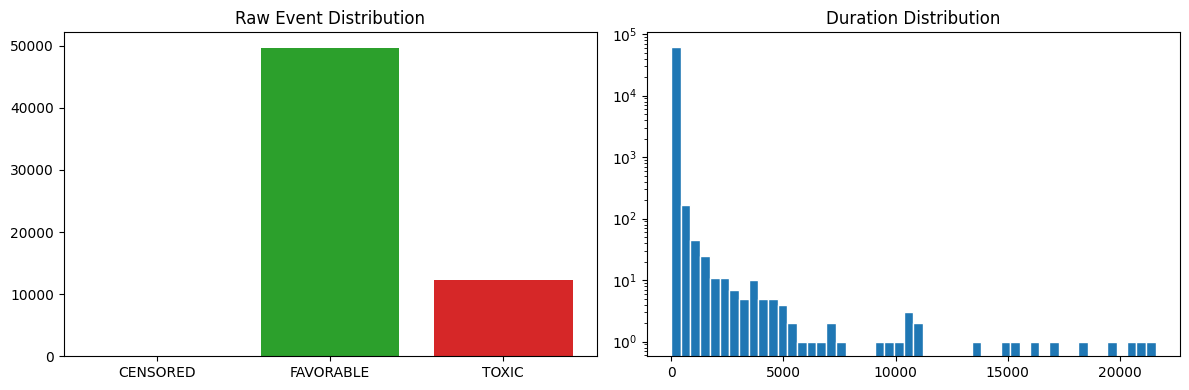

In [7]:
label_map = {0: "CENSORED", 1: "FAVORABLE_FILL", 2: "TOXIC_FILL"}
event_counts = df_raw["event_type"].value_counts().sort_index()

print("Raw event distribution (before train-based horizon censoring):")
for code in sorted(event_counts.index):
    print(f"  {code}: {label_map.get(int(code), f'UNKNOWN_{code}'):<20} - {event_counts[code]:>6}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(["CENSORED", "FAVORABLE", "TOXIC"], [event_counts.get(0, 0), event_counts.get(1, 0), event_counts.get(2, 0)], color=["#999999", "#2ca02c", "#d62728"])
ax[0].set_title("Raw Event Distribution")
ax[1].hist(df_raw["duration_s"], bins=50, color="#1f77b4", edgecolor="white")
ax[1].set_title("Duration Distribution")
ax[1].set_yscale("log")
plt.tight_layout()
plt.show()

## 3. Preprocess the Dataset
### 3a. Feature Extraction: LOB + Toxicity Dual Streams

In [8]:
LOOKBACK_STEPS = 500
LOB_FEATURE_DIM = 20
TOX_FEATURE_DIM = 12
SEED = 4718

X_lob = extract_lob_features(df_raw, LOOKBACK_STEPS, feat_dim=LOB_FEATURE_DIM)
X_tox = extract_toxicity_features(df_raw, LOOKBACK_STEPS, feat_dim=TOX_FEATURE_DIM)
X_all = np.concatenate([X_lob, X_tox], axis=2)

Y_all = df_raw["duration_s"].values.astype(np.float32)
D_all = df_raw["event_type"].values.astype(np.int64)

print(f"LOB features shape      : {X_lob.shape}")
print(f"Toxicity features shape : {X_tox.shape}")
print(f"Combined features shape : {X_all.shape}")
print(f"Duration vector shape   : {Y_all.shape}")
print(f"Event vector shape      : {D_all.shape}")

LOB features shape      : (62000, 500, 20)
Toxicity features shape : (62000, 500, 14)
Combined features shape : (62000, 500, 34)
Duration vector shape   : (62000,)
Event vector shape      : (62000,)


### 3b. Train / Validation / Test Split
### 3c. Feature Normalisation
### 3d. Discretise Continuous Durations
### 3e. Build PyTorch Datasets

In [9]:
entry_ns = df_raw["entry_time"].values
dates = pd.to_datetime(entry_ns, unit="ns", utc=True).tz_convert("America/New_York").normalize()
unique_days = sorted(dates.unique())
n_days = len(unique_days)
n = len(df_raw)

target_train_end = int(n * 0.70)
target_val_end = int(n * 0.85)
day_end_idx = [(dates <= d).sum() - 1 for d in unique_days]

train_day_idx = best_day_cut(target_train_end, day_end_idx)
val_day_idx = best_day_cut(target_val_end, day_end_idx)
train_day_idx = min(train_day_idx, n_days - 3)
val_day_idx = max(train_day_idx + 1, min(val_day_idx, n_days - 2))

train_end = day_end_idx[train_day_idx] + 1
val_end = day_end_idx[val_day_idx] + 1
idx = np.arange(n)

train_mask = idx < train_end
val_mask = (idx >= train_end) & (idx < val_end)
test_mask = idx >= val_end

T_MAX = choose_time_horizon_from_train_fills(
    durations=Y_all,
    events=D_all,
    train_mask=train_mask,
    fill_event_codes=(1, 2),
    quantile=95.0,
)

Y_all_h, D_all_h, n_late_uncensored = recensor_after_horizon(
    durations=Y_all,
    events=D_all,
    horizon=T_MAX,
)

X_train, Y_train, D_train = X_all[train_mask], Y_all_h[train_mask], D_all_h[train_mask]
X_val, Y_val, D_val = X_all[val_mask], Y_all_h[val_mask], D_all_h[val_mask]
X_test, Y_test, D_test = X_all[test_mask], Y_all_h[test_mask], D_all_h[test_mask]

label_map = {0: "CENSORED", 1: "FAVORABLE_FILL", 2: "TOXIC_FILL"}
train_event_counts = pd.Series(D_train).value_counts().sort_index()
print(f"T_MAX (95th percentile of training fill times): {T_MAX:.4f}s")
print(f"Late uncensored events re-censored at T_MAX: {n_late_uncensored}")
print("Training event distribution after horizon censoring:")
for code in sorted(train_event_counts.index):
    print(f"  {code}: {label_map.get(int(code), f'UNKNOWN_{code}'):<20} - {int(train_event_counts[code]):>6}")

feat_mean = X_train.mean(axis=(0, 1), keepdims=True)
feat_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
mask_col_idx = X_train.shape[2] - 1
feat_mean[..., mask_col_idx] = 0.0
feat_std[..., mask_col_idx] = 1.0

X_train_np = ((X_train - feat_mean) / feat_std).astype(np.float16)
X_val_np = ((X_val - feat_mean) / feat_std).astype(np.float16)
X_test_np = ((X_test - feat_mean) / feat_std).astype(np.float16)
X_train_np[..., mask_col_idx] = X_train[..., mask_col_idx]
X_val_np[..., mask_col_idx] = X_val[..., mask_col_idx]
X_test_np[..., mask_col_idx] = X_test[..., mask_col_idx]

NUM_TIME_STEPS = 30
label_transform = LabTransform(NUM_TIME_STEPS, scheme="quantiles")
Y_train_disc, D_train_disc = label_transform.fit_transform(Y_train.copy(), D_train.copy())
Y_val_disc, D_val_disc = label_transform.transform(Y_val.copy(), D_val.copy())
time_grid = label_transform.cuts
output_steps = len(time_grid)

X_train_t, Y_train_t, D_train_t = make_tensors(X_train_np, Y_train_disc, D_train_disc)
X_val_t, Y_val_t, D_val_t = make_tensors(X_val_np, Y_val_disc, D_val_disc)
train_data = list(zip(X_train_t, Y_train_t, D_train_t))
val_data = list(zip(X_val_t, Y_val_t, D_val_t))

print(f"Train samples: {len(train_data):,} | Val samples: {len(val_data):,} | Test samples: {len(X_test_np):,}")
print(f"Output time steps: {output_steps}")

T_MAX (95th percentile of training fill times): 44.4995s
Late uncensored events re-censored at T_MAX: 3119
Training event distribution after horizon censoring:
  0: CENSORED             -   2159
  1: FAVORABLE_FILL       -  32665
  2: TOXIC_FILL           -   8176
Train samples: 43,000 | Val samples: 10,000 | Test samples: 9,000
Output time steps: 30


## 4. Define the DeepHit Architecture (Imported from src/models)

Set `MODEL_NAME` to one of:
- `gru`
- `gru_transformer`
- `transformer`
- `mamba`

In [ ]:
MODEL_NAME = "mamba"
NUM_COMPETING_EVENTS = 2
EVENT_NAMES = ["FAVORABLE_FILL", "TOXIC_FILL"]
EVENT_CODES = [1, 2]

ALPHA = 0.5
SIGMA = 0.1
LEARNING_RATE = 1e-4
BATCH_SIZE = 1024
NUM_EPOCHS = 100
EARLY_STOP_PATIENCE = 12
USE_AUX_LOSS = False  # Set to True to use auxiliary next-step prediction loss
AUX_LOSS_WEIGHT = 0.1  # Weight for auxiliary loss in combined loss

feature_dim = X_train_t.size(2)

if MODEL_NAME == "gru":
    base_net = DeepHitRNNCompeting(
        num_features=feature_dim,
        num_events=NUM_COMPETING_EVENTS,
        num_time_steps=output_steps,
        hidden_size=160,
        num_layers=2,
        rnn_dropout=0.2,
        fc_hidden=256 if device.type != "cpu" else 128,
        fc_dropout=0.2,
    ).to(device)
elif MODEL_NAME == "gru_transformer":
    base_net = DeepHitRNNTransformerCompeting(
        num_features=feature_dim,
        num_events=NUM_COMPETING_EVENTS,
        num_time_steps=output_steps,
        hidden_size=96,
        num_layers=2,
        rnn_dropout=0.2,
        transformer_layers=2,
        transformer_heads=4,
        transformer_ff_dim=192,
        transformer_dropout=0.1,
        max_seq_len=X_train_t.size(1),
        fc_hidden=128 if device.type != "cpu" else 112,
        fc_dropout=0.2,
    ).to(device)
elif MODEL_NAME == "transformer":
    base_net = DeepHitTransformerCompeting(
        num_features=feature_dim,
        num_events=NUM_COMPETING_EVENTS,
        num_time_steps=output_steps,
        hidden_size=96,
        num_layers=2,
        num_heads=4,
        transformer_ff_dim=320,
        transformer_dropout=0.1,
        max_seq_len=X_train_t.size(1),
        fc_hidden=112,
        fc_dropout=0.2,
    ).to(device)
elif MODEL_NAME == "mamba":
    base_net = DeepHitMambaCompeting(
        num_features=feature_dim,
        num_events=NUM_COMPETING_EVENTS,
        num_time_steps=output_steps,
        hidden_size=144,
        num_mamba_layers=2,
        d_state=16,
        d_conv=4,
        expand=2,
        mamba_dropout=0.15,
        fc_dropout=0.2,
    ).to(device)
else:
    raise ValueError(f"Unknown MODEL_NAME: {MODEL_NAME}")

deephit_model = DeepHit(
    base_net,
    alpha=ALPHA,
    sigma=SIGMA,
    device=device,
    duration_index=time_grid,
)

total_params = sum(p.numel() for p in base_net.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME}")
print(f"Input shape: {tuple(X_train_t.shape)}")
print(f"Output shape: ({NUM_COMPETING_EVENTS}, {output_steps})")
print(f"Trainable params: {total_params:,}")
print(f"Using auxiliary loss: {USE_AUX_LOSS} (weight: {AUX_LOSS_WEIGHT})")

Model: gru
Input shape: (43000, 500, 34)
Output shape: (2, 30)
Trainable params: 410,269
Using auxiliary loss: False (weight: 0.1)


## 4b. Experiment Tracking (Weights & Biases)

W&B login credentials are loaded from `.env` (`WANDB_ENTITY`, `WANDB_API_KEY`).

In [11]:
import os
from datetime import datetime

import wandb
from dotenv import find_dotenv, load_dotenv

dotenv_path = find_dotenv(filename=".env", usecwd=True)
if dotenv_path:
    load_dotenv(dotenv_path=dotenv_path, override=False)
else:
    load_dotenv(override=False)

WANDB_ENABLE = True
WANDB_PROJECT = "test-runs"
WANDB_MODE = "online"
WANDB_ENTITY = os.environ.get("WANDB_ENTITY", "").strip()
WANDB_API_KEY = os.environ.get("WANDB_API_KEY", "").strip()
WANDB_RESUME_RUN_ID = os.environ.get("WANDB_RESUME_RUN_ID", "").strip()

if WANDB_RESUME_RUN_ID:
    WANDB_RUN_NAME = None
    WANDB_RUN_ID = WANDB_RESUME_RUN_ID
else:
    WANDB_RUN_NAME = f"static_deephit_{MODEL_NAME}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    WANDB_RUN_ID = None

wandb_run = None
if WANDB_ENABLE:
    if not WANDB_ENTITY:
        raise ValueError("WANDB_ENTITY is missing. Set it in .env (example: WANDB_ENTITY=your_wandb_team_or_username).")
    if not WANDB_API_KEY:
        raise ValueError("WANDB_API_KEY is missing. Set it in .env with your W&B API key.")

    os.environ["WANDB_API_KEY"] = WANDB_API_KEY
    wandb.login(key=WANDB_API_KEY, relogin=True)

    wandb_config = {
        "model_name": MODEL_NAME,
        "num_competing_events": NUM_COMPETING_EVENTS,
        "event_names": EVENT_NAMES,
        "alpha": ALPHA,
        "sigma": SIGMA,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "num_epochs": NUM_EPOCHS,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "use_aux_loss": USE_AUX_LOSS,
        "aux_loss_weight": AUX_LOSS_WEIGHT,
        "lookback_steps": LOOKBACK_STEPS,
        "lob_feature_dim": LOB_FEATURE_DIM,
        "tox_feature_dim": TOX_FEATURE_DIM,
        "train_samples": len(train_data),
        "val_samples": len(val_data),
        "test_samples": len(X_test_np),
        "output_steps": output_steps,
        "seed": SEED,
    }

    init_kwargs = {
        "project": WANDB_PROJECT,
        "entity": WANDB_ENTITY,
        "config": wandb_config,
        "mode": WANDB_MODE,
        "reinit": True,
    }

    if WANDB_RESUME_RUN_ID:
        init_kwargs["id"] = WANDB_RESUME_RUN_ID
        init_kwargs["resume"] = "allow"
        print(f"Resuming W&B run: {WANDB_RESUME_RUN_ID}")
    else:
        init_kwargs["name"] = WANDB_RUN_NAME
        print(f"Starting new W&B run: {WANDB_RUN_NAME}")

    wandb_run = wandb.init(**init_kwargs)
    wandb.define_metric("epoch")
    wandb.define_metric("train/*", step_metric="epoch")
    wandb.define_metric("val/*", step_metric="epoch")
    wandb.define_metric("train/lr", step_metric="epoch")
    print(f"W&B initialized: entity={WANDB_ENTITY}, project={WANDB_PROJECT}, run_id={wandb_run.id}")
else:
    print("W&B logging is disabled for this run.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /jet/home/ccheung1/.netrc
wandb: Currently logged in as: angus4718 (lob-deep-survival-analysis) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Starting new W&B run: static_deephit_gru_20260412_212516


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


W&B initialized: entity=lob-deep-survival-analysis, project=test-runs, run_id=18cs4lov


## 5. Train the DeepHit Model

In [13]:
# Clear stale GPU allocations from prior interrupted runs before re-launching training.
stale_vars = [
    "X_b", "Y_b", "D_b", "O_b", "U_b",
    "X_b_cpu", "Y_b_cpu", "D_b_cpu", "O_b_cpu", "U_b_cpu",
    "surv_logits", "total_loss", "val_total_loss", "loss_parts", "val_parts",
    "optimizer", "scheduler", "scaler",
    "x_b", "x_b_np", "logits_b", "pmf_b", "cif_b",
    "batch_sample_idx",
    "epoch_iterator",
    "batch_iter",
    "batch_indices",
    "idx_t",
    "sample_idx_batch",
    "oom_exc",
    "sample_count",
    "n_batches",
    "n_val_batches",
]

for _name in stale_vars:
    if _name in globals():
        del globals()[_name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()
    allocated_gb = torch.cuda.memory_allocated() / (1024 ** 3)
    reserved_gb = torch.cuda.memory_reserved() / (1024 ** 3)
    print(f"Post-cleanup CUDA memory: allocated={allocated_gb:.4f} GiB, reserved={reserved_gb:.4f} GiB")
else:
    print("CUDA not available; ran CPU-side garbage collection only.")

Post-cleanup CUDA memory: allocated=0.0716 GiB, reserved=0.0898 GiB


Epoch   2/100  train=2.3225  val=2.3505  (no improve: 1)
Epoch   4/100  train=2.2842  val=2.3310  (no improve: 3)
Epoch   6/100  train=2.2689  val=2.3133  (no improve: 0)
Epoch   8/100  train=2.2531  val=2.3066  (no improve: 0)
Epoch  10/100  train=2.2422  val=2.2895  (no improve: 0)
Epoch  12/100  train=2.2347  val=2.3827  (no improve: 2)
Epoch  14/100  train=2.2270  val=2.3798  (no improve: 4)
Epoch  16/100  train=2.2143  val=2.2770  (no improve: 1)
Epoch  18/100  train=2.2072  val=2.3504  (no improve: 3)
Epoch  20/100  train=2.1992  val=2.3578  (no improve: 5)
Epoch  22/100  train=2.1912  val=2.3389  (no improve: 1)
Epoch  24/100  train=2.1862  val=2.3415  (no improve: 3)
Epoch  26/100  train=2.1775  val=2.3520  (no improve: 5)
Epoch  28/100  train=2.1736  val=2.3260  (no improve: 7)
Epoch  30/100  train=2.1697  val=2.3048  (no improve: 9)
Epoch  32/100  train=2.1675  val=2.2464  (no improve: 0)
Epoch  34/100  train=2.1608  val=2.2164  (no improve: 1)
Epoch  36/100  train=2.1547  va

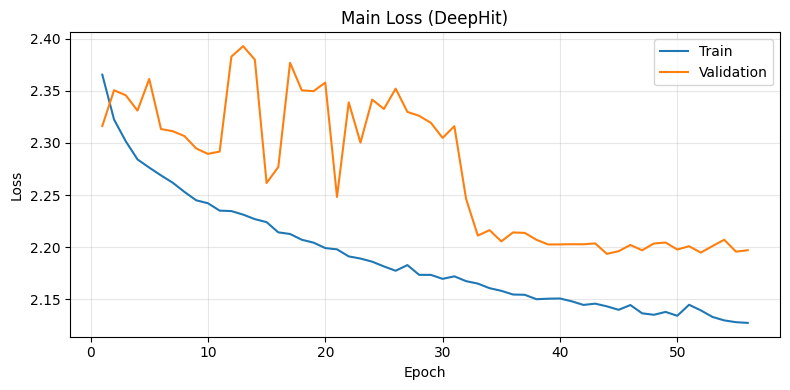

Logged training loss curves/table to W&B.


In [14]:
loader_num_workers = 0
loader_pin_memory = device.type != "cpu"

train_loader = DataLoader(train_data, BATCH_SIZE, shuffle=True, num_workers=loader_num_workers, pin_memory=loader_pin_memory)
val_loader = DataLoader(val_data, BATCH_SIZE, shuffle=False, num_workers=loader_num_workers, pin_memory=loader_pin_memory)

optimizer = torch.optim.Adam(base_net.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=LEARNING_RATE * 0.1)

train_losses, val_losses = [], []
train_aux_losses = [] if USE_AUX_LOSS else None
best_val_loss = float("inf")
best_params = None
best_epoch_idx = None
epochs_no_improve = 0

if wandb_run is not None:
    wandb_run.config.update(
        {
            "device": str(device),
            "feature_dim": int(feature_dim),
            "sequence_length": int(X_train_t.size(1)),
            "output_steps": int(output_steps),
            "total_params": int(total_params),
        },
        allow_val_change=True,
    )

for epoch in range(NUM_EPOCHS):
    base_net.train()
    epoch_loss = 0.0
    epoch_aux_loss = 0.0 if USE_AUX_LOSS else None
    n_batches = 0

    for X_b, Y_b, D_b in train_loader:
        X_b = X_b.to(device, non_blocking=loader_pin_memory)
        Y_b = Y_b.to(device, non_blocking=loader_pin_memory)
        D_b = D_b.to(device, non_blocking=loader_pin_memory)

        optimizer.zero_grad()
        surv_logits = base_net(X_b)
        rm = pair_rank_mat(Y_b.detach().cpu().numpy(), D_b.detach().cpu().numpy())
        rm_t = torch.tensor(rm, dtype=torch.int, device=device)

        # Main survival loss
        loss = deephit_model.loss(surv_logits, Y_b, D_b, rm_t)

        # Optional auxiliary loss
        if USE_AUX_LOSS and hasattr(base_net, "aux_next_step_loss"):
            aux_loss = base_net.aux_next_step_loss(X_b)
            combined_loss = loss + AUX_LOSS_WEIGHT * aux_loss
            epoch_aux_loss += aux_loss.item()
        else:
            combined_loss = loss

        combined_loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_loss = epoch_loss / n_batches
    train_aux_loss = None
    if USE_AUX_LOSS:
        train_aux_loss = epoch_aux_loss / n_batches
        train_aux_losses.append(train_aux_loss)

    base_net.eval()
    val_loss_total = 0.0
    n_val_batches = 0
    with torch.no_grad():
        for X_b, Y_b, D_b in val_loader:
            X_b = X_b.to(device, non_blocking=loader_pin_memory)
            Y_b = Y_b.to(device, non_blocking=loader_pin_memory)
            D_b = D_b.to(device, non_blocking=loader_pin_memory)

            surv_logits = base_net(X_b)
            rm = pair_rank_mat(Y_b.detach().cpu().numpy(), D_b.detach().cpu().numpy())
            rm_t = torch.tensor(rm, dtype=torch.int, device=device)
            loss = deephit_model.loss(surv_logits, Y_b, D_b, rm_t)

            val_loss_total += loss.item()
            n_val_batches += 1

    val_loss = val_loss_total / n_val_batches
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step()
    current_lr = float(optimizer.param_groups[0]["lr"])

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch_idx = epoch
        best_params = deepcopy(base_net.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if wandb_run is not None:
        log_payload = {
            "epoch": epoch + 1,
            "train/loss": float(train_loss),
            "val/loss": float(val_loss),
            "train/lr": current_lr,
            "train/epochs_no_improve": int(epochs_no_improve),
            "train/use_aux_loss": bool(USE_AUX_LOSS),
        }
        if train_aux_loss is not None:
            log_payload["train/aux_loss"] = float(train_aux_loss)
        wandb_run.log(log_payload, step=epoch + 1)

    if (epoch + 1) % 2 == 0:
        aux_loss_str = f"  aux={train_aux_loss:.4f}" if USE_AUX_LOSS and train_aux_loss is not None else ""
        print(f"Epoch {epoch+1:>3}/{NUM_EPOCHS}  train={train_loss:.4f}{aux_loss_str}  val={val_loss:.4f}  (no improve: {epochs_no_improve})")

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (no val improvement for {EARLY_STOP_PATIENCE} epochs)")
        break

if best_params is not None:
    base_net.load_state_dict(best_params)

print(f"Best val loss {best_val_loss:.4f} at epoch {best_epoch_idx + 1 if best_epoch_idx is not None else -1}")

if wandb_run is not None:
    wandb_run.summary["best_val_loss"] = float(best_val_loss)
    wandb_run.summary["best_epoch"] = int(best_epoch_idx + 1 if best_epoch_idx is not None else -1)

fig, axes = plt.subplots(1, 2 if USE_AUX_LOSS else 1, figsize=(8 if not USE_AUX_LOSS else 12, 4))
if not USE_AUX_LOSS:
    axes = [axes]

axes[0].plot(range(1, len(train_losses) + 1), train_losses, label="Train")
axes[0].plot(range(1, len(val_losses) + 1), val_losses, label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Main Loss (DeepHit)")
axes[0].grid(alpha=0.3)
axes[0].legend()

if USE_AUX_LOSS and train_aux_losses:
    axes[1].plot(range(1, len(train_aux_losses) + 1), train_aux_losses, label="Aux Loss", color="#ff7f0e")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MSE Loss")
    axes[1].set_title("Auxiliary Loss (Next-Step Prediction)")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

plt.tight_layout()
plt.show()

if wandb_run is not None:
    loss_history_df = {
        "epoch": list(range(1, len(train_losses) + 1)),
        "train_loss": train_losses,
        "val_loss": val_losses,
    }
    if USE_AUX_LOSS and train_aux_losses:
        loss_history_df["train_aux_loss"] = train_aux_losses
    loss_history_df = pd.DataFrame(loss_history_df)
    wandb_run.log(
        {
            "plots/loss_curves": wandb.Image(fig),
            "tables/loss_history": wandb.Table(dataframe=loss_history_df),
        }
    )
    print("Logged training loss curves/table to W&B.")

## 6. Evaluate Model Performance
### 6a. Predict Cause-Specific CIFs on the Test Set
### 6b. Cause-Specific Concordance

In [15]:
base_net.eval()
cif_test = deephit_model.predict_cif(
    X_test_np.astype("float32"),
    batch_size=BATCH_SIZE,
    to_cpu=True,
    numpy=True,
)

print(f"CIF array shape: {cif_test.shape} (K, T, N)")

ctd_scores = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    one_minus_cif_df = pd.DataFrame(1 - cif_test[k, :, :], index=time_grid)
    ev = EvalSurv(one_minus_cif_df, Y_test, (D_test == event_code).astype(int), censor_surv="km")
    ctd = ev.concordance_td("antolini")
    ctd_scores[event_name] = ctd
    print(f"  {event_name:<20}: C-td = {ctd:.4f}")

macro_ctd = float(np.mean(list(ctd_scores.values())))
n_fav_test = (D_test == 1).sum()
n_tox_test = (D_test == 2).sum()
n_events_test = n_fav_test + n_tox_test
weighted_ctd = (n_fav_test * ctd_scores["FAVORABLE_FILL"] + n_tox_test * ctd_scores["TOXIC_FILL"]) / n_events_test if n_events_test > 0 else 0.0

print(f"Macro-average C-td: {macro_ctd:.4f}")
print(f"Weighted C-td: {weighted_ctd:.4f}")

if wandb_run is not None:
    ctd_log = {
        "eval/ctd_macro": float(macro_ctd),
        "eval/ctd_weighted": float(weighted_ctd),
    }
    for event_name, ctd_value in ctd_scores.items():
        ctd_log[f"eval/ctd_{event_name.lower()}"] = float(ctd_value)
    wandb_run.log(ctd_log)
    wandb_run.summary["eval_ctd_macro"] = float(macro_ctd)
    wandb_run.summary["eval_ctd_weighted"] = float(weighted_ctd)
    print("Logged C-td metrics to W&B.")
else:
    print("W&B run not active; skipped C-td logging.")

CIF array shape: (2, 30, 9000) (K, T, N)
  FAVORABLE_FILL      : C-td = 0.6113
  TOXIC_FILL          : C-td = 0.6547
Macro-average C-td: 0.6330
Weighted C-td: 0.6200
Logged C-td metrics to W&B.


### 6c. Distribution of Predicted Cause-Specific Fill Probabilities

Compare final-time CIF predictions for favorable and toxic risks across true outcome groups.

Test set composition:
  CENSORED      : 470
  FAVORABLE_FILL: 6812
  TOXIC_FILL    : 1718

Predicted final CIF means at t=21588.9s:
  True FAVORABLE -> CIF(FAVORABLE): 0.6660
  True TOXIC     -> CIF(TOXIC)    : 0.3387


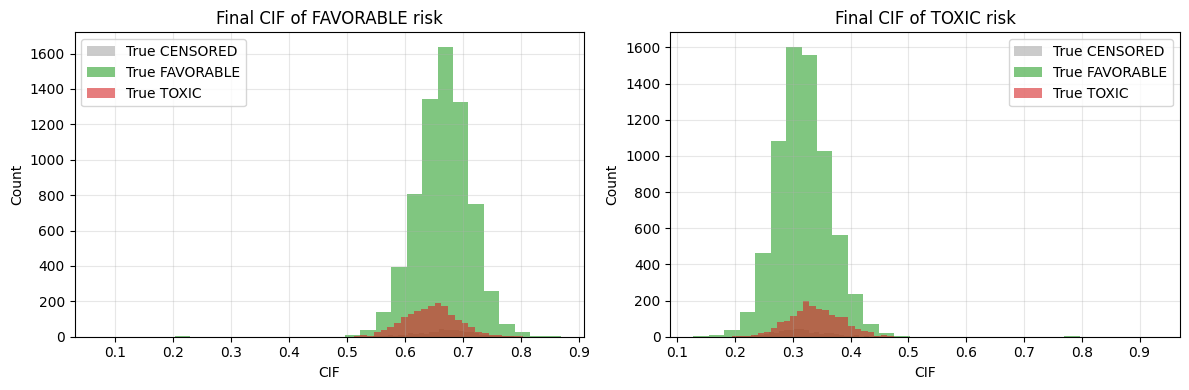

In [16]:
# Final-time cause-specific probabilities
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]

mask_cens = (D_test == 0)
mask_fav = (D_test == 1)
mask_tox = (D_test == 2)

print("Test set composition:")
print(f"  CENSORED      : {int(mask_cens.sum())}")
print(f"  FAVORABLE_FILL: {int(mask_fav.sum())}")
print(f"  TOXIC_FILL    : {int(mask_tox.sum())}")

print(f"\nPredicted final CIF means at t={time_grid[-1]:.1f}s:")
if mask_fav.any():
    print(f"  True FAVORABLE -> CIF(FAVORABLE): {final_cif_fav[mask_fav].mean():.4f}")
if mask_tox.any():
    print(f"  True TOXIC     -> CIF(TOXIC)    : {final_cif_tox[mask_tox].mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(final_cif_fav[mask_cens], bins=30, alpha=0.5, label="True CENSORED", color="#999999")
axes[0].hist(final_cif_fav[mask_fav], bins=30, alpha=0.6, label="True FAVORABLE", color="#2ca02c")
axes[0].hist(final_cif_fav[mask_tox], bins=30, alpha=0.6, label="True TOXIC", color="#d62728")
axes[0].set_title("Final CIF of FAVORABLE risk")
axes[0].set_xlabel("CIF")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(final_cif_tox[mask_cens], bins=30, alpha=0.5, label="True CENSORED", color="#999999")
axes[1].hist(final_cif_tox[mask_fav], bins=30, alpha=0.6, label="True FAVORABLE", color="#2ca02c")
axes[1].hist(final_cif_tox[mask_tox], bins=30, alpha=0.6, label="True TOXIC", color="#d62728")
axes[1].set_title("Final CIF of TOXIC risk")
axes[1].set_xlabel("CIF")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6d. Integrated Brier Score

Compute time-dependent standard Brier scores and integrated Brier score (IBS) for each competing event.

Integrated Brier Score (IBS) per event:
  FAVORABLE_FILL      : IBS = 0.1908  |  Uninformed = 0.1841
  TOXIC_FILL          : IBS = 0.1650  |  Uninformed = 0.1544
Macro-average IBS: 0.1779
Macro-average IBS (uninformed): 0.1692
Weighted IBS: 0.1856
Weighted IBS (uninformed): 0.1781


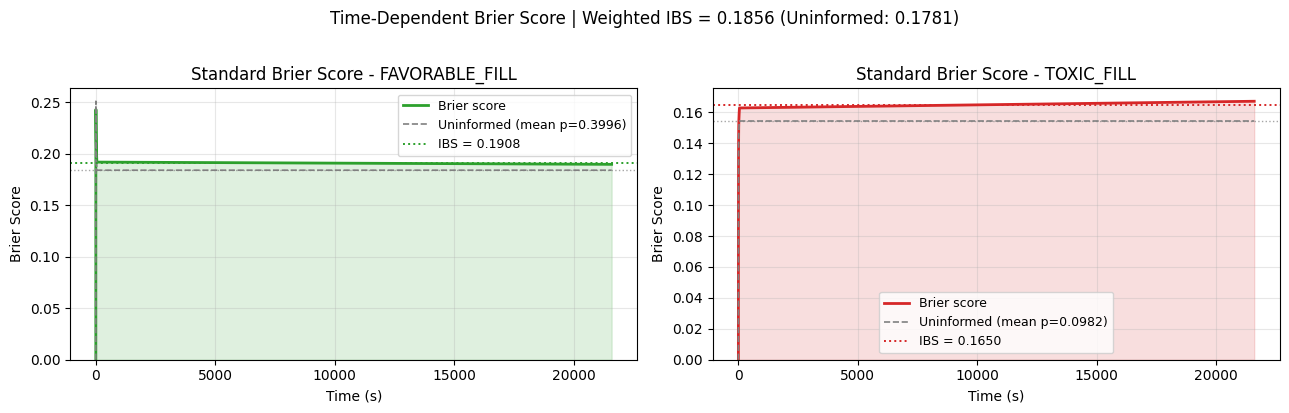

Logged IBS metrics to W&B.


In [17]:
bs_curves = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    bs_curves[event_name] = standard_brier_score(
        durations=Y_test,
        events=D_test,
        cif_k=cif_test[k],
        event_code=event_code,
        time_grid=time_grid,
    )

p_fav_train_curve = uninformed_cif_curve_from_train(Y_train, D_train, 1, time_grid)
p_tox_train_curve = uninformed_cif_curve_from_train(Y_train, D_train, 2, time_grid)
bs_curves_uninformed = {
    "FAVORABLE_FILL": uninformed_brier_score(Y_test, D_test, p_fav_train_curve, 1, time_grid),
    "TOXIC_FILL": uninformed_brier_score(Y_test, D_test, p_tox_train_curve, 2, time_grid),
}

t_min, t_max = float(time_grid[0]), float(time_grid[-1])
_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

ibs_scores = {}
ibs_scores_uninformed = {}
for event_name, bs_arr in bs_curves.items():
    ibs_scores[event_name] = _trapz(bs_arr, time_grid) / (t_max - t_min)
    ibs_scores_uninformed[event_name] = _trapz(bs_curves_uninformed[event_name], time_grid) / (t_max - t_min)

macro_ibs = float(np.mean(list(ibs_scores.values())))
macro_ibs_uninformed = float(np.mean(list(ibs_scores_uninformed.values())))

n_fav_test = int((D_test == 1).sum())
n_tox_test = int((D_test == 2).sum())
n_events_test = n_fav_test + n_tox_test
weighted_ibs = (
    (n_fav_test * ibs_scores["FAVORABLE_FILL"] + n_tox_test * ibs_scores["TOXIC_FILL"]) / n_events_test
    if n_events_test > 0
    else 0.0
)
weighted_ibs_uninformed = (
    (n_fav_test * ibs_scores_uninformed["FAVORABLE_FILL"] + n_tox_test * ibs_scores_uninformed["TOXIC_FILL"]) / n_events_test
    if n_events_test > 0
    else 0.0
)

print("Integrated Brier Score (IBS) per event:")
for event_name in EVENT_NAMES:
    print(
        f"  {event_name:<20}: IBS = {ibs_scores[event_name]:.4f}  |  Uninformed = {ibs_scores_uninformed[event_name]:.4f}"
    )
print(f"Macro-average IBS: {macro_ibs:.4f}")
print(f"Macro-average IBS (uninformed): {macro_ibs_uninformed:.4f}")
print(f"Weighted IBS: {weighted_ibs:.4f}")
print(f"Weighted IBS (uninformed): {weighted_ibs_uninformed:.4f}")

colors_bs = {"FAVORABLE_FILL": "#2ca02c", "TOXIC_FILL": "#d62728"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, event_name in zip(axes, EVENT_NAMES):
    bs_arr = bs_curves[event_name]
    ibs_val = ibs_scores[event_name]
    ibs_uninf_val = ibs_scores_uninformed[event_name]
    color = colors_bs.get(event_name, "#1f77b4")
    baseline_curve = p_fav_train_curve if event_name == "FAVORABLE_FILL" else p_tox_train_curve

    ax.plot(time_grid, bs_arr, color=color, linewidth=2, label="Brier score")
    ax.fill_between(time_grid, bs_arr, alpha=0.15, color=color)
    ax.plot(
        time_grid,
        bs_curves_uninformed[event_name],
        color="grey",
        linestyle="--",
        linewidth=1.2,
        label=f"Uninformed (mean p={baseline_curve.mean():.4f})",
    )
    ax.axhline(ibs_uninf_val, color="grey", linestyle=":", linewidth=1, alpha=0.7)
    ax.axhline(ibs_val, color=color, linestyle=":", linewidth=1.4, label=f"IBS = {ibs_val:.4f}")
    ax.set_title(f"Standard Brier Score - {event_name}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Brier Score")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(
    f"Time-Dependent Brier Score | Weighted IBS = {weighted_ibs:.4f} (Uninformed: {weighted_ibs_uninformed:.4f})",
    fontsize=12,
    y=1.02,
 )
plt.tight_layout()
plt.show()

if wandb_run is not None:
    ibs_log = {
        "eval/ibs_macro": float(macro_ibs),
        "eval/ibs_macro_uninformed": float(macro_ibs_uninformed),
        "eval/ibs_weighted": float(weighted_ibs),
        "eval/ibs_weighted_uninformed": float(weighted_ibs_uninformed),
    }
    for event_name in EVENT_NAMES:
        ibs_log[f"eval/ibs_{event_name.lower()}"] = float(ibs_scores[event_name])
        ibs_log[f"eval/ibs_{event_name.lower()}_uninformed"] = float(ibs_scores_uninformed[event_name])
    wandb_run.log(ibs_log)
    wandb_run.summary["eval_ibs_weighted"] = float(weighted_ibs)
    wandb_run.summary["eval_ibs_macro"] = float(macro_ibs)
    print("Logged IBS metrics to W&B.")
else:
    print("W&B run not active; skipped IBS logging.")

### 6e. Visualize Competing CIFs for Sample Orders

Plot favorable-risk CIF, toxic-risk CIF, and implied survival for sample test orders.

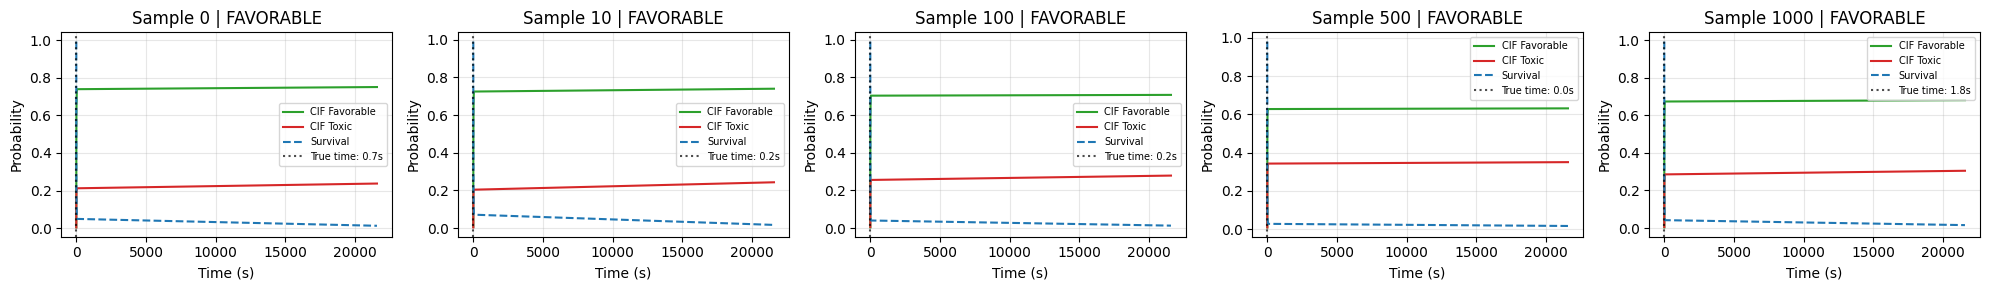

In [18]:
sample_indices = [0, 10, 100, 500, 1000]
sample_indices = [i for i in sample_indices if i < len(X_test_np)]

fig, axes = plt.subplots(1, len(sample_indices), figsize=(4 * max(1, len(sample_indices)), 3))
if len(sample_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_indices):
    cif_fav = cif_test[0, :, idx]
    cif_tox = cif_test[1, :, idx]
    surv_curve = 1.0 - (cif_fav + cif_tox)

    true_time = float(Y_test[idx])
    true_event = int(D_test[idx])
    true_label = "FAVORABLE" if true_event == 1 else ("TOXIC" if true_event == 2 else "CENSORED")

    ax.plot(time_grid, cif_fav, label="CIF Favorable", color="#2ca02c")
    ax.plot(time_grid, cif_tox, label="CIF Toxic", color="#d62728")
    ax.plot(time_grid, surv_curve, label="Survival", color="#1f77b4", linestyle="--")
    ax.axvline(true_time, color="black", linestyle=":", alpha=0.7, label=f"True time: {true_time:.1f}s")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Probability")
    ax.set_title(f"Sample {idx} | {true_label}")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6f. PR-AUC and ROC-AUC Evaluation

Primary metric under imbalance: Precision-Recall AUC (Average Precision).

Secondary metric for threshold-invariant ranking context: ROC-AUC.

PR-AUC (Average Precision, OvR):
  Macro AP   : 0.3778
  Weighted AP: 0.6668
  CENSORED            : AP = 0.0485  (random baseline=0.0522)
  FAVORABLE_FILL      : AP = 0.8077  (random baseline=0.7569)
  TOXIC_FILL          : AP = 0.2772  (random baseline=0.1909)


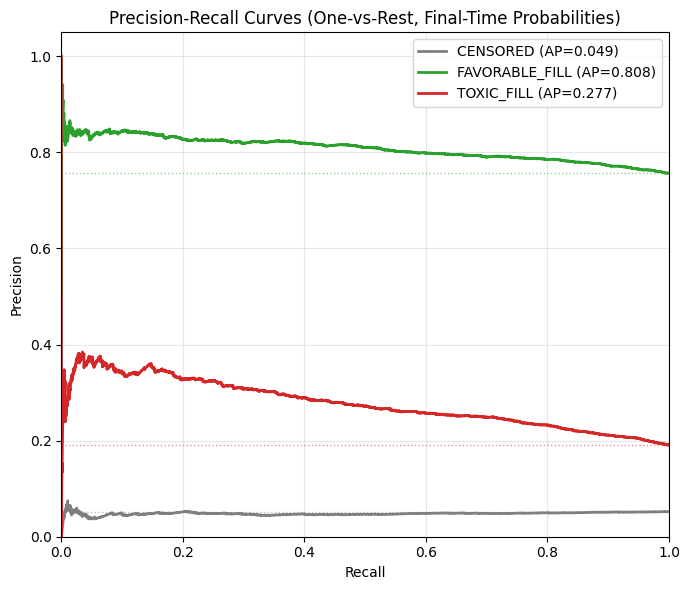


Event-only PR-AUC (FAVORABLE vs TOXIC):
  Samples              : 8530
  AP (toxic as positive): 0.2888
  Random baseline       : 0.2014


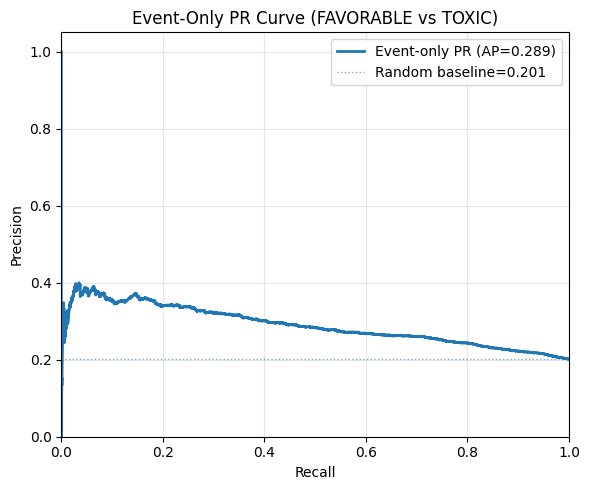


ROC-AUC (OvR):
  Macro AUC   : 0.5644
  Weighted AUC: 0.5953

Censoring diagnostics
Censored samples: 470 / 9000 (5.2%)
Mean survival (censored): 0.0157
Mean survival (events)  : 0.0160
Difference              : -0.0003
Censored with survival > 0.5: 0 / 470 (0.0%)

BASELINE MODEL METRICS SUMMARY
Best_Val_Loss             : 2.1937
Best_Epoch                : 44
Favorable_Ctd             : 0.6113
Toxic_Ctd                 : 0.6547
Weighted_Ctd              : 0.6200
AP_Macro_OvR              : 0.3778
AP_Weighted_OvR           : 0.6668
AP_Event_Only             : 0.2888
AUC_Macro_OvR             : 0.5644
AUC_Weighted_OvR          : 0.5953
Weighted_IBS              : 0.1856
Total_Params              : 410,269
Logged PR/AUC metrics and summary table to W&B.


In [19]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]
final_surv = np.clip(1.0 - (final_cif_fav + final_cif_tox), 0.0, 1.0)

# Scores for classes [0=censored, 1=favorable, 2=toxic]
y_true = D_test.astype(int)
class_labels = [0, 1, 2]
class_names = {0: "CENSORED", 1: "FAVORABLE_FILL", 2: "TOXIC_FILL"}
proba_event = np.vstack([final_surv, final_cif_fav, final_cif_tox]).T
y_true_bin = label_binarize(y_true, classes=class_labels)

# -----------------------------
# Primary: PR-AUC (AP)
# -----------------------------
ap_macro_ovr = average_precision_score(y_true_bin, proba_event, average="macro")
ap_weighted_ovr = average_precision_score(y_true_bin, proba_event, average="weighted")

pr_curves = {}
ap_per_class = {}
prevalence_per_class = {}
for i, cls in enumerate(class_labels):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], proba_event[:, i])
    pr_curves[cls] = (precision, recall)
    ap_per_class[cls] = average_precision_score(y_true_bin[:, i], proba_event[:, i])
    prevalence_per_class[cls] = float((y_true == cls).mean())

print("PR-AUC (Average Precision, OvR):")
print(f"  Macro AP   : {ap_macro_ovr:.4f}")
print(f"  Weighted AP: {ap_weighted_ovr:.4f}")
for cls in class_labels:
    print(
        f"  {class_names[cls]:<20}: AP = {ap_per_class[cls]:.4f}  (random baseline={prevalence_per_class[cls]:.4f})"
    )

fig, ax = plt.subplots(figsize=(7, 6))
colors = {0: "#7f7f7f", 1: "#2ca02c", 2: "#d62728"}
for cls in class_labels:
    precision, recall = pr_curves[cls]
    ax.plot(
        recall,
        precision,
        color=colors[cls],
        lw=2,
        label=f"{class_names[cls]} (AP={ap_per_class[cls]:.3f})",
    )
    ax.hlines(
        prevalence_per_class[cls],
        xmin=0,
        xmax=1,
        colors=colors[cls],
        linestyles=":",
        linewidth=1,
        alpha=0.5,
    )
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves (One-vs-Rest, Final-Time Probabilities)")
ax.grid(alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# Event-only PR-AUC: FAVORABLE vs TOXIC (exclude censored)
has_event_mask = (y_true == 1) | (y_true == 2)
n_event_samples = int(has_event_mask.sum())
if n_event_samples > 1 and len(np.unique(y_true[has_event_mask])) == 2:
    y_true_events = y_true[has_event_mask]
    # Positive class is TOXIC_FILL (code 2)
    y_true_events_binary = (y_true_events == 2).astype(int)
    score_toxic = final_cif_tox[has_event_mask]
    precision_ev, recall_ev, _ = precision_recall_curve(y_true_events_binary, score_toxic)
    ap_event_only = average_precision_score(y_true_events_binary, score_toxic)
    toxic_prevalence_events = float(y_true_events_binary.mean())

    print("\nEvent-only PR-AUC (FAVORABLE vs TOXIC):")
    print(f"  Samples              : {n_event_samples}")
    print(f"  AP (toxic as positive): {ap_event_only:.4f}")
    print(f"  Random baseline       : {toxic_prevalence_events:.4f}")

    fig_event, ax_event = plt.subplots(figsize=(6, 5))
    ax_event.plot(recall_ev, precision_ev, color="#1f77b4", lw=2, label=f"Event-only PR (AP={ap_event_only:.3f})")
    ax_event.hlines(
        toxic_prevalence_events,
        xmin=0,
        xmax=1,
        colors="#1f77b4",
        linestyles=":",
        linewidth=1,
        alpha=0.6,
        label=f"Random baseline={toxic_prevalence_events:.3f}",
    )
    ax_event.set_xlim([0.0, 1.0])
    ax_event.set_ylim([0.0, 1.05])
    ax_event.set_xlabel("Recall")
    ax_event.set_ylabel("Precision")
    ax_event.set_title("Event-Only PR Curve (FAVORABLE vs TOXIC)")
    ax_event.grid(alpha=0.3)
    ax_event.legend(loc="best")
    plt.tight_layout()
    plt.show()
else:
    ap_event_only = float("nan")
    print("\nEvent-only PR-AUC skipped (insufficient non-censored class variety).")

# -----------------------------
# Secondary: ROC-AUC
# -----------------------------
auc_macro_ovr = roc_auc_score(y_true_bin, proba_event, average="macro", multi_class="ovr")
auc_weighted_ovr = roc_auc_score(y_true_bin, proba_event, average="weighted", multi_class="ovr")

print("\nROC-AUC (OvR):")
print(f"  Macro AUC   : {auc_macro_ovr:.4f}")
print(f"  Weighted AUC: {auc_weighted_ovr:.4f}")

# Keep censoring diagnostics
is_censored = y_true == 0
n_censored = int(is_censored.sum())
surv_prob_censored = final_surv[is_censored]
surv_prob_events = final_surv[has_event_mask] if has_event_mask.any() else np.array([0.0])

avg_surv_censored = float(surv_prob_censored.mean()) if n_censored > 0 else 0.0
avg_surv_events = float(surv_prob_events.mean())
threshold = 0.5
correct_cens = int((surv_prob_censored > threshold).sum()) if n_censored > 0 else 0

print("\nCensoring diagnostics")
print(f"Censored samples: {n_censored} / {len(y_true)} ({100 * is_censored.mean():.1f}%)")
print(f"Mean survival (censored): {avg_surv_censored:.4f}")
print(f"Mean survival (events)  : {avg_surv_events:.4f}")
print(f"Difference              : {avg_surv_censored - avg_surv_events:+.4f}")
if n_censored > 0:
    print(f"Censored with survival > {threshold}: {correct_cens} / {n_censored} ({100 * correct_cens / n_censored:.1f}%)")

metrics_summary = {
    "Best_Val_Loss": f"{best_val_loss:.4f}" if best_val_loss is not None else "N/A",
    "Best_Epoch": best_epoch_idx + 1 if best_epoch_idx is not None else "N/A",
    "Favorable_Ctd": f"{ctd_scores.get('FAVORABLE_FILL', 0):.4f}",
    "Toxic_Ctd": f"{ctd_scores.get('TOXIC_FILL', 0):.4f}",
    "Weighted_Ctd": f"{weighted_ctd:.4f}",
    "AP_Macro_OvR": f"{ap_macro_ovr:.4f}",
    "AP_Weighted_OvR": f"{ap_weighted_ovr:.4f}",
    "AP_Event_Only": f"{ap_event_only:.4f}" if np.isfinite(ap_event_only) else "N/A",
    "AUC_Macro_OvR": f"{auc_macro_ovr:.4f}",
    "AUC_Weighted_OvR": f"{auc_weighted_ovr:.4f}",
    "Weighted_IBS": f"{weighted_ibs:.4f}" if "weighted_ibs" in globals() else "N/A",
    "Total_Params": f"{total_params:,}",
}

print("\n" + "=" * 70)
print("BASELINE MODEL METRICS SUMMARY")
print("=" * 70)
for key, value in metrics_summary.items():
    print(f"{key:<25} : {value}")
print("=" * 70)

if wandb_run is not None:
    pr_log = {
        "eval/ap_macro_ovr": float(ap_macro_ovr),
        "eval/ap_weighted_ovr": float(ap_weighted_ovr),
        "eval/auc_macro_ovr": float(auc_macro_ovr),
        "eval/auc_weighted_ovr": float(auc_weighted_ovr),
        "eval/weighted_ctd": float(weighted_ctd),
    }
    if np.isfinite(ap_event_only):
        pr_log["eval/ap_event_only"] = float(ap_event_only)
    for cls in class_labels:
        pr_log[f"eval/ap_{class_names[cls].lower()}"] = float(ap_per_class[cls])
    wandb_run.log(pr_log)

    pr_weighted_df = pd.DataFrame(
        {
            "recall": pr_curves[2][1],
            "precision": pr_curves[2][0],
        }
    )
    wandb_run.log(
        {
            "plots/pr_curve_ovr": wandb.Image(fig),
            "tables/pr_curve_toxic_ovr": wandb.Table(dataframe=pr_weighted_df),
        }
    )

    for key, value in metrics_summary.items():
        try:
            wandb_run.summary[f"summary/{key}"] = float(value)
        except Exception:
            wandb_run.summary[f"summary/{key}"] = str(value)
    print("Logged PR/AUC metrics and summary table to W&B.")
else:
    print("W&B run not active; skipped PR/AUC logging.")

mamba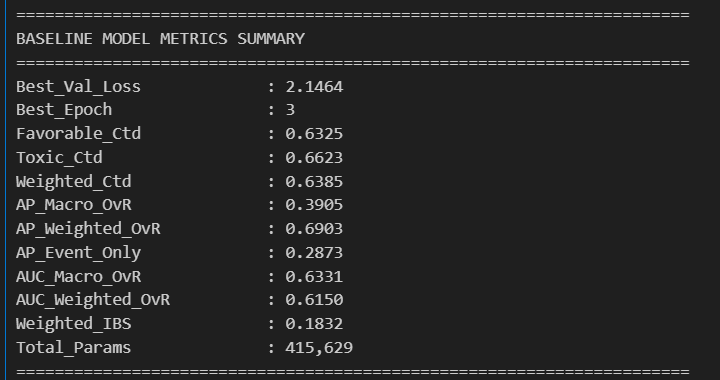

gru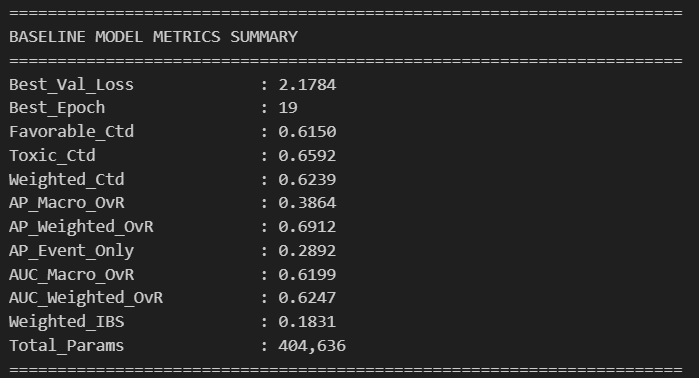

transformer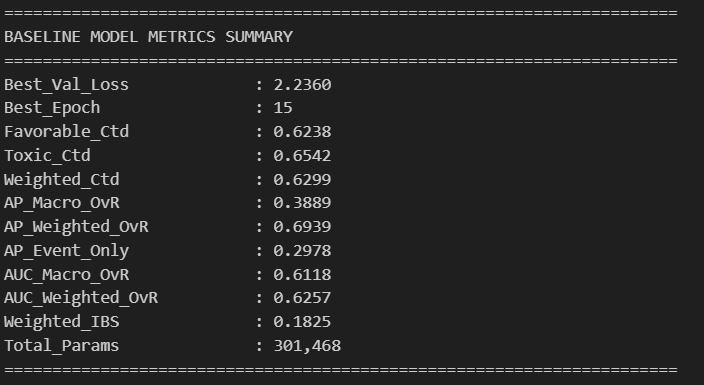

gru_transformer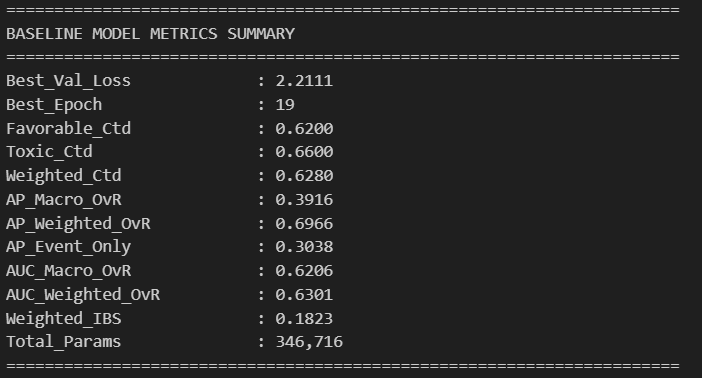

mamba small lr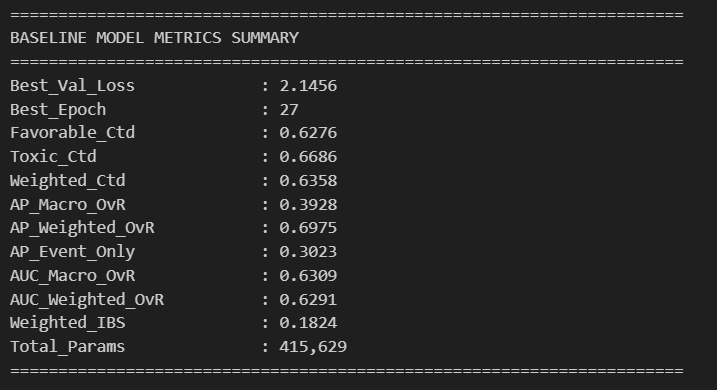

gru_transformer small lr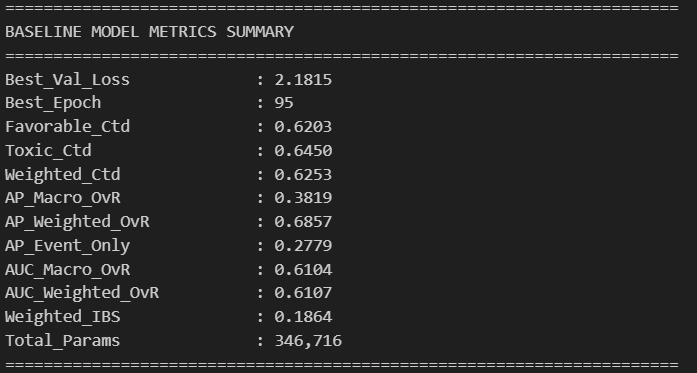

## 7. Save Model Artifacts

In [20]:
artifact_dir = PROJECT_ROOT / "artifacts" / "baseline"
artifact_dir.mkdir(parents=True, exist_ok=True)

model_save_path = artifact_dir / f"standardized_deephit_{MODEL_NAME}_base_net.pt"
meta_save_path = artifact_dir / f"standardized_deephit_{MODEL_NAME}_meta.pt"

torch.save(base_net.state_dict(), model_save_path)
metadata = {
    "model_name": MODEL_NAME,
    "num_competing_events": NUM_COMPETING_EVENTS,
    "event_names": EVENT_NAMES,
    "output_steps": output_steps,
    "time_grid": time_grid,
    "lookback_steps": LOOKBACK_STEPS,
    "learning_rate": LEARNING_RATE,
    "best_epoch": best_epoch_idx + 1 if best_epoch_idx is not None else None,
    "best_val_loss": best_val_loss,
}
torch.save(metadata, meta_save_path)

print(f"Model saved to: {model_save_path.relative_to(PROJECT_ROOT)}")
print(f"Metadata saved to: {meta_save_path.relative_to(PROJECT_ROOT)}")

if wandb_run is not None and not bool(getattr(wandb_run, "_is_finished", False)):
    model_artifact = wandb.Artifact(
        name=f"standardized_static_deephit_{MODEL_NAME}_{wandb_run.id}",
        type="model",
    )
    model_artifact.add_file(str(model_save_path))
    model_artifact.add_file(str(meta_save_path))
    wandb_run.log_artifact(model_artifact)
    wandb_run.summary["models_uploaded_to_wandb"] = True
    wandb_run.finish()
    print("Uploaded model artifacts and finished W&B run.")
else:
    print("W&B run not active; skipped artifact upload.")

Model saved to: artifacts/baseline/standardized_deephit_gru_base_net.pt
Metadata saved to: artifacts/baseline/standardized_deephit_gru_meta.pt


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
eval/ap_censored,▁
eval/ap_event_only,▁
eval/ap_favorable_fill,▁
eval/ap_macro_ovr,▁
eval/ap_toxic_fill,▁
eval/ap_weighted_ovr,▁
eval/auc_macro_ovr,▁
eval/auc_weighted_ovr,▁
eval/ctd_favorable_fill,▁
+16,...


Uploaded model artifacts and finished W&B run.
